# 01 — EDA: tickets ITSM sintéticos

Exploración del dataset de la **Fase 1** y validación de los patrones que el sintetizador inyecta (ver `src/itops/data/synthesizer.py` y `data/README.md`).

**Objetivos de validación:**
1. Ratio de escalación cercano al 5%.
2. Estacionalidad horaria y semanal visible.
3. Diferencias de escalación por tier de cliente.
4. Detección visual de las anomalías sembradas.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from itops.config import SEEDED_ANOMALIES_JSON
from itops.data.loader import load_tickets

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = load_tickets()
anomalies = json.loads(SEEDED_ANOMALIES_JSON.read_text())['anomalies']
df.shape

Matplotlib is building the font cache; this may take a moment.


(50000, 17)

## 1. Calidad de datos: tipos y nulos

Revisar dtypes y nulos antes de cualquier análisis.

In [2]:
df.dtypes

ticket_id                           str
created_at               datetime64[us]
closed_at                datetime64[ns]
category                            str
subcategory                         str
priority_initial                    str
priority_final                      str
assigned_team                       str
assignee_id                         str
customer_tier                       str
description                         str
response_time_minutes             int64
num_comments                      int64
num_reassignments                 int64
business_hours                     bool
escalated                          bool
hours_to_escalation             float64
dtype: object

In [3]:
nulls = df.isna().sum()
nulls[nulls > 0]  # solo closed_at (tickets abiertos) y hours_to_escalation (no escalados)

closed_at               1905
hours_to_escalation    47596
dtype: int64

In [4]:
df.head()

,ticket_id,created_at,closed_at,category,subcategory,priority_initial,priority_final,assigned_team,assignee_id,customer_tier,description,response_time_minutes,num_comments,num_reassignments,business_hours,escalated,hours_to_escalation
0,INC0000001,2024-01-01 00:17:21,2024-01-01 04:23:18.361031811,access,provisioning,medium,medium,team_d,agent_050,basic,Provisioning issue reported. Agent every devel...,11,0,4,False,False,NaN
1,INC0000002,2024-01-01 00:26:01,2024-01-01 23:41:55.629824086,other,misc,high,high,team_e,agent_055,basic,Misc issue reported. Beautiful instead ahead d...,15,7,1,False,False,NaN
2,INC0000003,2024-01-01 00:51:50,NaT,network,latency,medium,medium,team_a,agent_035,basic,Latency issue reported: service is critical. E...,25,0,1,False,False,NaN
3,INC0000004,2024-01-01 01:23:46,NaT,access,permissions,low,low,team_d,agent_034,basic,Permissions issue reported. Suggest page south...,73,1,2,False,False,NaN
4,INC0000005,2024-01-01 04:30:04,2024-01-01 17:08:06.647653936,access,mfa,high,high,team_d,agent_062,standard,Mfa issue reported. Peace technology officer r...,12,3,1,False,False,NaN


## 2. Ratio de escalación

Debe estar cerca del 5% objetivo (el intercepto del logit se calibra por bisección).

In [5]:
escalation_rate = df['escalated'].mean()
print(f'Ratio de escalación: {escalation_rate:.2%}')
assert 0.03 <= escalation_rate <= 0.07, 'fuera del rango esperado'

Ratio de escalación: 4.81%


## 3. Estacionalidad horaria y semanal

Picos esperados: 9-11h y 14-16h; peak semanal los lunes.

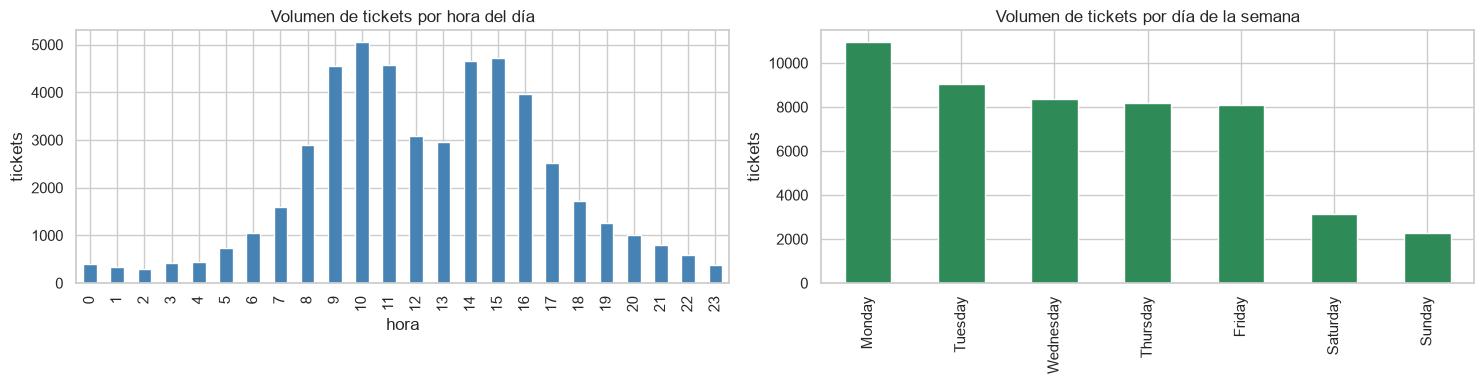

In [6]:
df['hour'] = df['created_at'].dt.hour
df['weekday'] = df['created_at'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set(title='Volumen de tickets por hora del día', xlabel='hora', ylabel='tickets')

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'].value_counts().reindex(order).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set(title='Volumen de tickets por día de la semana', xlabel='', ylabel='tickets')
plt.tight_layout()
plt.show()

## 4. Diferencias por tier de cliente

`enterprise` debe escalar ~3× más que `basic`. También comparamos por categoría.

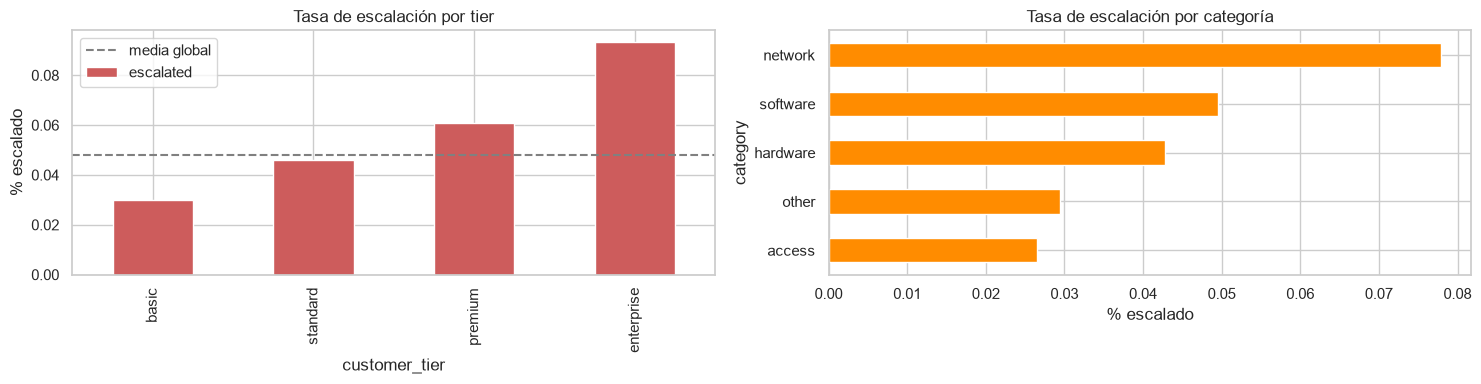

enterprise / basic = 3.11x


In [7]:
tier_order = ['basic', 'standard', 'premium', 'enterprise']
by_tier = df.groupby('customer_tier')['escalated'].mean().reindex(tier_order)
by_category = df.groupby('category')['escalated'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
by_tier.plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set(title='Tasa de escalación por tier', ylabel='% escalado')
axes[0].axhline(escalation_rate, ls='--', c='gray', label='media global')
axes[0].legend()
by_category.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set(title='Tasa de escalación por categoría', xlabel='% escalado')
plt.tight_layout()
plt.show()

print(f"enterprise / basic = {by_tier['enterprise'] / by_tier['basic']:.2f}x")

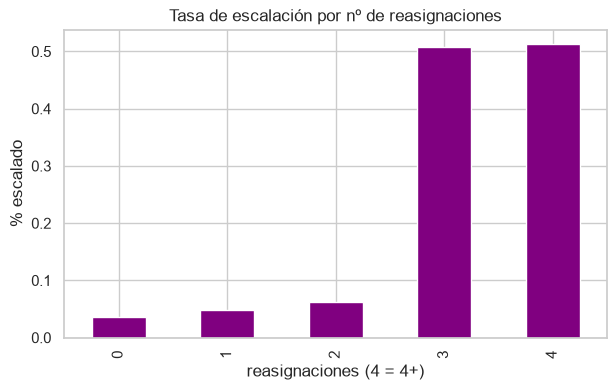

group
0    0.035329
1    0.048930
2    0.062063
3    0.507177
4    0.512500
Name: escalated, dtype: float64

In [8]:
# Reasignaciones: >2 debería rondar el 50% de escalación.
reassign = df.assign(group=df['num_reassignments'].clip(upper=4))\
    .groupby('group')['escalated'].mean()
reassign.plot(kind='bar', color='purple', figsize=(7, 4),
              title='Tasa de escalación por nº de reasignaciones')
plt.ylabel('% escalado'); plt.xlabel('reasignaciones (4 = 4+)'); plt.show()
reassign

## 5. Detección visual de anomalías sembradas

Conteo diario por categoría. Los días marcados (verdad-base de `seeded_anomalies.json`) deben sobresalir claramente como bursts de una sola categoría.

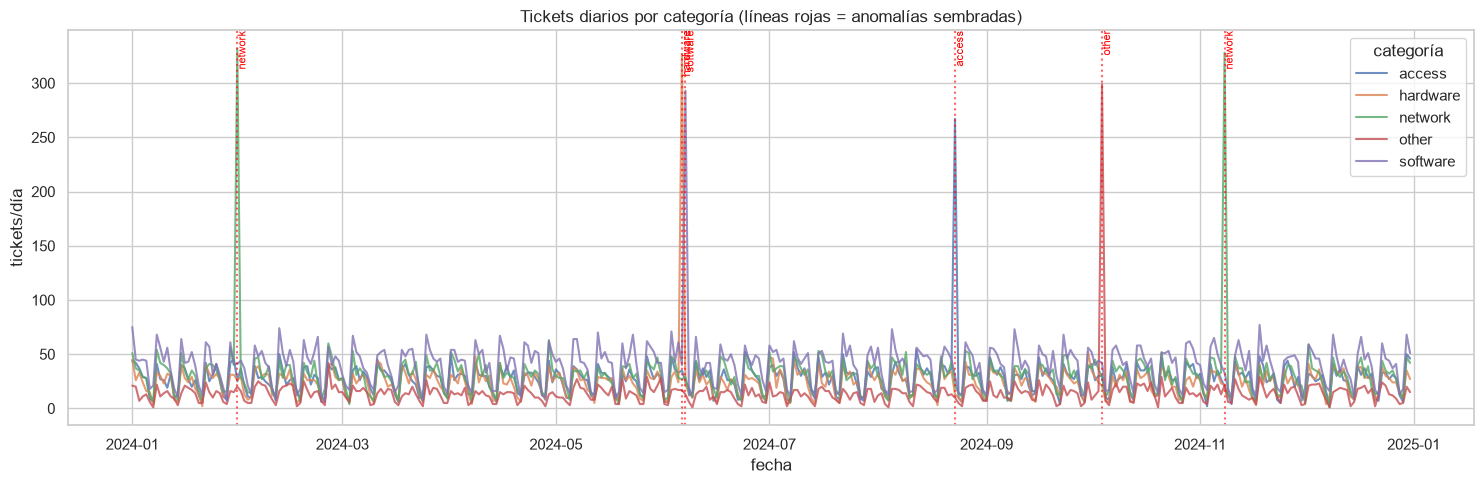

In [9]:
daily = df.groupby([df['created_at'].dt.date, 'category']).size().rename('count').reset_index()
daily['created_at'] = pd.to_datetime(daily['created_at'])

categories = daily['category'].unique()
fig, ax = plt.subplots(figsize=(15, 5))
for cat in categories:
    sub = daily[daily['category'] == cat]
    ax.plot(sub['created_at'], sub['count'], label=cat, alpha=0.8)

for a in anomalies:
    ax.axvline(pd.Timestamp(a['date']), color='red', ls=':', alpha=0.6)
    ax.annotate(a['category'], (pd.Timestamp(a['date']), ax.get_ylim()[1]),
                rotation=90, va='top', fontsize=8, color='red')

ax.set(title='Tickets diarios por categoría (líneas rojas = anomalías sembradas)',
       xlabel='fecha', ylabel='tickets/día')
ax.legend(title='categoría')
plt.tight_layout()
plt.show()

In [10]:
# Verificación cuantitativa: cada burst supera media + 3 desv. de su categoría.
rows = []
for a in anomalies:
    per_day = daily[daily['category'] == a['category']].set_index('created_at')['count']
    threshold = per_day.mean() + 3 * per_day.std()
    observed = per_day.loc[pd.Timestamp(a['date'])]
    rows.append({'date': a['date'], 'category': a['category'],
                 'observed': int(observed), 'threshold': round(threshold, 1),
                 'detected': bool(observed > threshold)})
pd.DataFrame(rows)

,date,category,observed,threshold,detected
0,2024-01-31,network,332,108.3,True
1,2024-06-06,hardware,326,82.1,True
2,2024-06-07,software,293,105.3,True
3,2024-08-23,access,267,79.3,True
4,2024-10-04,other,299,63.3,True
5,2024-11-08,network,328,108.3,True


## Conclusiones

- **Ratio de escalación** calibrado cerca del 5%.
- **Estacionalidad** horaria (picos 9-11h / 14-16h) y semanal (peak lunes) visible.
- **Tier**: `enterprise` escala ~3× más que `basic`; `network` es la categoría de mayor riesgo.
- **Reasignaciones** > 2 disparan la escalación a ~50%.
- **Anomalías sembradas** detectables visual y cuantitativamente.

El dataset tiene la señal necesaria para la Fase 2 (anomaly detection) y la Fase 3 (escalation).